# Tasks
## Accounts and repositories
Reuse your account, repository and Streamlit app from the previous part of the project work.
Until peer review and feedback have been completed, push to a temporary GitHub branch for later merging.
## API
Familiarise yourself with the API connection at https://open-meteo.com/en/docsLenker til en ekstern side.
Observe how you can select features and produce Python code.
Be aware of multiple sub-sections that alter which type of data is selected.


## Jupyter Notebook


- Use Oslo, Kristiansand, Trondheim, Tromsø and Bergen as representatives for the five electricity price areas in Norway. Find their geographical centre points in longitude and latitude. Save price area codes, city names, longitude and latitude in a Pandas data frame.

In [1]:
import pandas as pd

city_data = {
    'pricearea':['NO1', 'NO2', 'NO3', 'NO4', 'NO5'],
    'city_names':['Oslo','Kristiansand', 'Trondheim', 'Tromsø', 'Bergen'],
    'lon':[10.7461, 7.9956, 10.3951, 18.957, 5.328],
    'lat':[59.9127, 58.1467, 63.4305, 69.6496, 60.392]
}

df = pd.DataFrame(city_data)
df.head

<bound method NDFrame.head of   pricearea    city_names      lon      lat
0       NO1          Oslo  10.7461  59.9127
1       NO2  Kristiansand   7.9956  58.1467
2       NO3     Trondheim  10.3951  63.4305
3       NO4        Tromsø  18.9570  69.6496
4       NO5        Bergen   5.3280  60.3920>

- Use the open-meteo API to retrieve historical reanalysis data using the ERA5 model for a single location as follows:  
  - Create a function for the API download task that takes a pair of longitude and latitude values, plus a year as input and downloads the same weather properties as were used in the CSV file in part 1 of the project work.

In [2]:
# Function for the API download task that takes a pair of longtitude and latitude values, plus a year as input
# and downlods the same weather propserties
# temperature_2m (°C)	precipitation (mm)	wind_speed_10m (m/s)	wind_gusts_10m (m/s)	wind_direction_10m (°)

import requests
import pandas as pd

def get_era5_data(latitude: float, longitude: float, year: str) -> pd.DataFrame | None:
    """
    Get historical ERA5 weather data from Open-Meteo.

    Args:
        latitude (float): Latitude coordinate (e.g., 52.52).
        longitude (float): Longitude coordinate (e.g., 13.41).
        year (str): Start date in 'YYYY' format (e.g., '2019').

    Returns:
        pd.DataFrame or None: A Pandas DataFrame with the hourly weather data,
                              or None if the API request fails.
    """
    
    # Define the API endpoint and the required hourly variables
    BASE_URL = "https://archive-api.open-meteo.com/v1/era5"
    
    start_date = year + "-01-01"
    end_date = year + "-12-31"

    # The properties
    Properties = [
        "temperature_2m", 
        "precipitation", 
        "wind_speed_10m", 
        "wind_gusts_10m", 
        "wind_direction_10m"
    ]
    
    # Construct the parameters dictionary
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": Properties,
        "timezone": "auto",
        "models": "era5", 
        "wind_speed_unit": "ms" 
    }
    
    # Make the API request
    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
        data = response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return None

    # Process the JSON response into a Pandas DataFrame
    # The 'hourly' key contains the time series data
    hourly_data = data.get("hourly", {})
    
    if not hourly_data:
        print("API response is missing 'hourly' data.")
        return None
        
    df = pd.DataFrame(hourly_data)
    
    # Convert the 'time' column to a datetime index
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')

    return df



  - Apply the function to download data for Bergen for the year 2019.

In [3]:
# Bergen
LAT = 60.392
LON = 5.328

YEAR = "2019"

# Call the function
df_Bergen = get_era5_data(LAT, LON, YEAR)

if df_Bergen is not None:
    print("Bergens hourly weather data, 2019")
    print(df_Bergen.head())
    print(f"\nDataFrame Shape: {df_Bergen.shape}")


Bergens hourly weather data, 2019
                     temperature_2m  precipitation  wind_speed_10m  \
time                                                                 
2019-01-01 00:00:00             7.2            0.3           10.95   
2019-01-01 01:00:00             7.1            0.4           12.20   
2019-01-01 02:00:00             7.3            0.5           13.08   
2019-01-01 03:00:00             7.5            0.7           14.01   
2019-01-01 04:00:00             7.0            0.5           14.29   

                     wind_gusts_10m  wind_direction_10m  
time                                                     
2019-01-01 00:00:00            24.2                 265  
2019-01-01 01:00:00            26.4                 280  
2019-01-01 02:00:00            23.7                 293  
2019-01-01 03:00:00            25.5                 309  
2019-01-01 04:00:00            28.5                 314  

DataFrame Shape: (8760, 5)


### Outliers and anomalies:
- Plot the temperature as a function of time.
    - Perform a high-pass filtering of the temperature using Direct Cosine Transfer to create seasonally adjusted temperature variations (SATV).
    - Add curves to the plot indicating Statistical Process Control boundaries between inliers and outliers based on the SATV according to robust statistics estimated from the whole year. Colour outliers with a contrasting colour. Do not plot SATV values; only use them to find boundaries and outliers.
    - Let the frequency cut-off for the DCT and the number of standard deviations be parameters with sensible defaults.
    - Wrap this in a function that returns the plot and relevant summaries of the outliers, and test the function.


In [4]:
# Function to 
# Perform a high-pass filtering of the temperature using Direct Cosine Transfer 
# to create seasonally adjusted temperature variations (SATV).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
from typing import Tuple, Dict, Any

def calculate_satv(temperature_series: pd.Series, dct_cutoff: int = 3) -> pd.Series:
    """
    Performs high-pass filtering using DCT to calculate Seasonally Adjusted 
    Temperature Variations (SATV), removing the first 'cutoff_count' DCT coefficients.
    """
    T = temperature_series.values
    N = len(T)

    # Apply Forward DCT
    T_dct = dct(T, type=1, norm='forward')

    # Define High-Pass Filter Coefficients
    T_dct_hp = T_dct.copy()
    
    if dct_cutoff >= 0 and dct_cutoff <= N:
        # Zero out the low-frequency coefficients (k=0 up to cutoff_count-1)
        T_dct_hp[:dct_cutoff] = 0
    else:
        raise ValueError("cutoff_count must be between 0 and the length of the time series.")

    # Apply Inverse DCT
    SATV_values = idct(T_dct_hp, type=1, norm='forward')

    # Return as a Pandas Series
    return pd.Series(SATV_values, index=temperature_series.index)

In [5]:
# Add curves to the plot indicating Statistical Process Control boundaries between inliers and outliers 
# based on the SATV according to robust statistics estimated from the whole year. 
# Colour outliers with a contrasting colour. 
# The frequency cut-off for the DCT and the number of standard deviations be parameters with sensible defaults.

def plot_anomaly_control(
    df: pd.DataFrame, 
    temp_col: str = 'temperature_2m', 
    dct_cutoff: int = 3, 
    std_dev_multiple: float = 3.0,
    figsize: Tuple[int, int] = (12, 6)
) -> Tuple[plt.Figure, Dict[str, Any]]:
    
    """
    Plots the original temperature data with Statistical Process Control boundaries 
    based on Seasonally Adjusted Temperature Variations (SATV).
    """
    if temp_col not in df.columns:
        raise ValueError(f"Column '{temp_col}' not found in DataFrame.")

    # Calculate SATV 
    temp_series = df[temp_col]
    # Pass the renamed parameter
    satv_series = calculate_satv(temp_series, dct_cutoff=dct_cutoff) 

    # Estimate Robust Statistics from SATV
    median = satv_series.median()
    mad = (satv_series - median).abs().median()
    robust_std = mad * 1.4826 
    
    # Define the controll/SATV limits  
    upper_satv_limit = median + std_dev_multiple * robust_std
    lower_satv_limit = median - std_dev_multiple * robust_std

    # Identify Outliers
    outlier_mask = (satv_series > upper_satv_limit) | (satv_series < lower_satv_limit)
    outliers = df[outlier_mask]

    # Calculate Control Boundaries for the Original Temperature Data
    seasonal_cycle = temp_series - satv_series
    upper_boundary = seasonal_cycle + upper_satv_limit
    lower_boundary = seasonal_cycle + lower_satv_limit

    # Plott the results
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the original temperature data (inliers)
    ax.plot(
        df.index, df[temp_col], 
        label=f'Original {temp_col}', 
        color='blue', 
        linewidth=1
    )
    
    # Plot the control boundaries
    ax.plot(upper_boundary, label=f'{std_dev_multiple} MAD Upper Limit', color='red', linestyle='--')
    ax.plot(lower_boundary, label=f'{std_dev_multiple} MAD Lower Limit', color='red', linestyle='--')
    
    # Colour outliers 
    ax.scatter(
        outliers.index, outliers[temp_col], 
        color='gold', 
        edgecolor='black', 
        s=40,
        zorder=5,
        label='Outliers'
    )

    # Set plot aesthetics (Updated title to reflect the new parameter name)
    ax.set_title(
        f'Temperature Outlier Detection (DCT Cutoff $\\rightarrow$ {dct_cutoff}, \
        {std_dev_multiple} $\\times$ MAD)', fontsize=12)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'{temp_col} (°C)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    # Prepare Summary
    summary = {
        'total_observations': len(df),
        'number_of_outliers': len(outliers),
        'percentage_outliers': (len(outliers) / len(df)) * 100,
        'robust_median': median,
        'robust_std_estimate': robust_std,
        'outlier_data': outliers[[temp_col]]
    }
    
    return fig, summary

In [6]:
# --- Setup Example Data for Testing (Requires df_Bergen to be loaded) ---

dates = pd.date_range('2019-01-01', periods=365*24, freq='h')
t_index = np.arange(365*24)
seasonal_cycle = 10 * np.sin(2 * np.pi * t_index / (365*24)) # Annual cycle
noise = np.random.normal(0, 1.5, len(dates)) # Normal variation

# Add an extreme outlier for testing
noise[1000:1010] += 10 
noise[2000:2050] -= 5 
noise[4500:4510] -= 7 
noise[6540:6550] += 5 

temperature = 5 + seasonal_cycle + noise
df_Bergen_tmp = pd.DataFrame({'temperature_2m': temperature}, index=dates)

--- Test 1:

Summary 1:
Total Observations: 8760
Number of Outliers: 0
Percentage Outliers: 0.00%
Robust Median of SATV: 0.01
First 5 Outlier Records:
Empty DataFrame
Columns: [temperature_2m]
Index: []


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


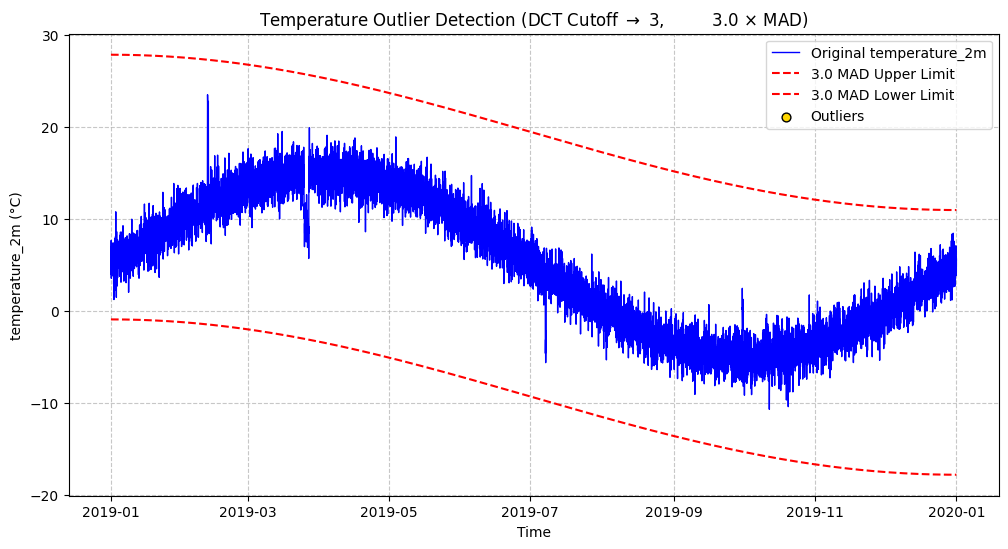

In [7]:
# --- Test 1
selected_dct_cutoff=3 
selected_std_dev_multiple = 3.0


print("--- Test 1:")
plot1, summary1 = plot_anomaly_control(
    df_Bergen_tmp, 
    temp_col = 'temperature_2m', 
    dct_cutoff = selected_dct_cutoff, 
    std_dev_multiple = selected_std_dev_multiple
    )

print("\nSummary 1:")
print(f"Total Observations: {summary1['total_observations']}")
print(f"Number of Outliers: {summary1['number_of_outliers']}")
print(f"Percentage Outliers: {summary1['percentage_outliers']:.2f}%")
print(f"Robust Median of SATV: {summary1['robust_median']:.2f}")
print("First 5 Outlier Records:")
print(summary1['outlier_data'].head())

plt.show() # Uncomment to display the plot


--- Test 2

Summary 2:
Total Observations: 8760
Number of Outliers: 51
Percentage Outliers: 0.58%
Robust Median of SATV: 0.01
First 5 Outlier Records:
                     temperature_2m
2019-01-01 04:00:00        3.559201
2019-01-01 16:00:00        3.832004
2019-01-02 04:00:00        2.927276
2019-01-02 06:00:00        2.869374
2019-01-02 07:00:00        1.253199


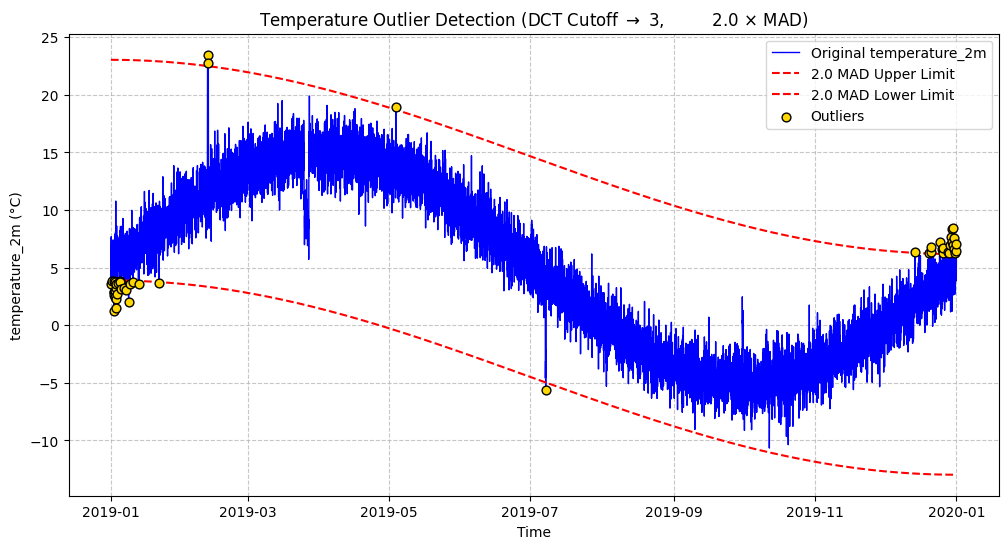

In [8]:
# --- Test 2
selected_dct_cutoff = 3 
selected_std_dev_multiple = 2.0

print("\n--- Test 2")
plot2, summary2 = plot_anomaly_control(
    df_Bergen_tmp, 
    temp_col = 'temperature_2m', 
    dct_cutoff = selected_dct_cutoff,
    std_dev_multiple = selected_std_dev_multiple)

print("\nSummary 2:")
print(f"Total Observations: {summary2['total_observations']}")
print(f"Number of Outliers: {summary2['number_of_outliers']}")
print(f"Percentage Outliers: {summary2['percentage_outliers']:.2f}%")
print(f"Robust Median of SATV: {summary2['robust_median']:.2f}")
print("First 5 Outlier Records:")
print(summary2['outlier_data'].head())
plt.show() # Uncomment to display the second plot

- Plot the precipitation as a function of time.
    - Indicate anomalies according to the Local Outlier Factor method.
    - Let the proportion of outliers be a parameter defaulting to 1%.
    - Wrap this in a function that returns the plot and relevant summaries of the outliers, and test the function.

                     temperature_2m  precipitation  wind_speed_10m  \
time                                                                 
2019-01-01 00:00:00             7.2            0.3           10.95   
2019-01-01 01:00:00             7.1            0.4           12.20   
2019-01-01 02:00:00             7.3            0.5           13.08   
2019-01-01 03:00:00             7.5            0.7           14.01   
2019-01-01 04:00:00             7.0            0.5           14.29   

                     wind_gusts_10m  wind_direction_10m  
time                                                     
2019-01-01 00:00:00            24.2                 265  
2019-01-01 01:00:00            26.4                 280  
2019-01-01 02:00:00            23.7                 293  
2019-01-01 03:00:00            25.5                 309  
2019-01-01 04:00:00            28.5                 314  


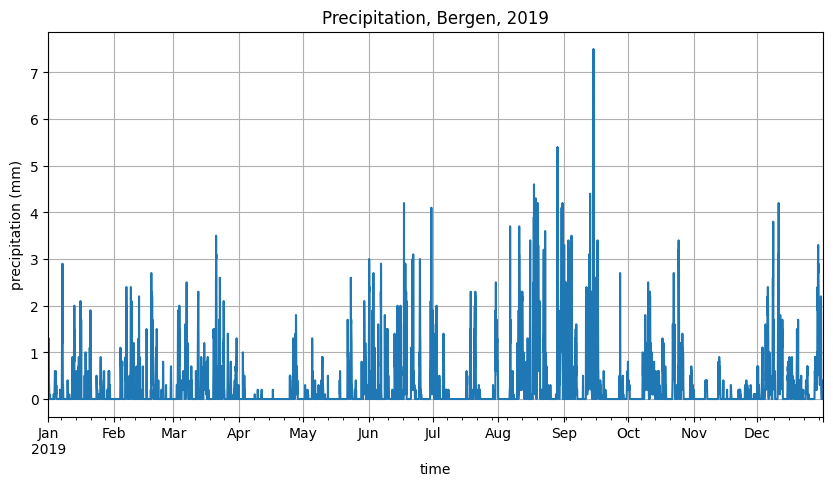

In [9]:
import matplotlib.pyplot as plt

print(df_Bergen.head())

plt.figure(figsize=(10,5))

df_Bergen['precipitation'].plot(
    title='Precipitation, Bergen, 2019',
    ylabel='precipitation (mm)'
)

plt.grid()
plt.show()

In [10]:
# Function 
# to calculate anomalies according to the Local Outlier Factor method
# to summarize the outliers
# plot the result

import numpy as np
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Any


def calculate_LOF_anomalies(
    df_full: pd.DataFrame, 
    feature_col: str, 
    n_neighbors: int, 
    contamination: float
) -> Tuple[plt.Figure, pd.DataFrame]:

    """
    Calcurate anomalies according to the Local Outlier Factor method, 
    summarize of the outliers and plot the result

    Args:
        df_full (pd.DataFrame): The full DataFrame containing the feature to analyze 
                                and all context columns (e.g., 'temperature_2m').
        feature_col (str): The name of the column to run LOF on (e.g., 'precipitation').
        n_neighbors (int): Number of neighbors to use for LOF.
        contamination (float): The proportion of outliers expected in the dataset.

    Returns:
        Tuple[plt.Figure, pd.DataFrame]: The generated matplotlib Figure and 
                                         a DataFrame summarizing the outliers.
     
    """

    # Filter out potential NaNs for robust LOF calculation
    df_clean = df_full.dropna(subset=[feature_col]).copy()

    # Run LOF Analysis
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    pred_labels = lof.fit_predict(X=df_clean)
    
    # Store scores and labels back into the clean DataFrame
    df_clean['LOF_Label'] = pred_labels
    df_clean['LOF_Score'] = np.clip(lof.negative_outlier_factor_, -10, 0)

    # Separate Inliers/Outliers and Calculate Baseline
    inliers = df_clean[df_clean['LOF_Label'] == 1]
    outliers = df_clean[df_clean['LOF_Label'] == -1]

    median_baseline = df_clean[feature_col].median()
    mean_baseline = df_clean[feature_col].mean()

    # for Statistical Summary
    total_samples = len(df_clean)
    num_outliers = len(outliers)
    outlier_percentage = (num_outliers / total_samples) * 100
    
    stats_summary = {
        'total_samples': total_samples,
        'num_outliers': num_outliers,
        'outlier_percentage': f'{outlier_percentage:.2f}%' # Format to 2 decimal places
    }

    # Generate Plot
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot the inliers using the time index
    ax.plot(inliers.index, inliers[feature_col], 'o', alpha=0.5, label='Inlier')

    # Plot the outliers using the time index
    ax.plot(outliers.index, outliers[feature_col], 'o', color='red', label='Outlier')
 
    # Plot Aesthetics
    ax.set_xlabel('Time')
    ax.set_ylabel(f'{feature_col}') 
    ax.axhline(mean_baseline, color='gray', linestyle=':', label='Mean Baseline')
    ax.legend(loc='upper right')
    ax.set_title(f'{feature_col.capitalize()} Anomaly Detection using LOF (n_neighbors={n_neighbors}, Contamination={contamination})')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout() # Adjust layout to prevent clipping

    # Prepare Summary DataFrame
    # Use localized formatting to display clean output
    pd.set_option('display.float_format', '{:.2f}'.format)

    outlier_summary = outliers.copy()

    # Add Baseline Metrics
    outlier_summary['Median_Baseline'] = median_baseline
    outlier_summary['Absolute_Deviation'] = (outlier_summary[feature_col] - mean_baseline).abs()

    # Select and rename final columns for the summary
    summary_cols = {
        feature_col: feature_col.capitalize(),
        'LOF_Score': 'LOF_Score',
        'Median_Baseline': 'Median_Baseline',
        'Absolute_Deviation': 'Absolute_Deviation',
    }
    
    # Add temperature and wind if they exist in the original DataFrame
    if 'temperature_2m' in df_full.columns:
        summary_cols['temperature_2m'] = 'Temperature'
    if 'wind_gusts_10m' in df_full.columns:
        summary_cols['wind_gusts_10m'] = 'Wind_Gusts'
    
    # Final selection and sorting (by LOF_Score for most severe first)
    outlier_summary_final = outlier_summary[summary_cols.keys()] \
        .rename(columns=summary_cols) \
        .sort_values(by='LOF_Score')

    return fig, outlier_summary_final, stats_summary


--- TEST 1 (n_neighbors=20, Contamination=0.01) ---
Statistics: {'total_samples': 8760, 'num_outliers': 88, 'outlier_percentage': '1.00%'}
Outlier Summary Head:
                      Precipitation  LOF_Score  Median_Baseline  \
time                                                             
2019-01-01 04:00:00           0.50      -2.60             0.00   
2019-01-01 06:00:00           0.40      -2.59             0.00   
2019-01-01 05:00:00           1.30      -2.53             0.00   
2019-01-01 03:00:00           0.70      -2.38             0.00   
2019-01-01 07:00:00           0.50      -2.35             0.00   

                     Absolute_Deviation  Temperature  Wind_Gusts  
time                                                              
2019-01-01 04:00:00                0.26         7.00       28.50  
2019-01-01 06:00:00                0.16         6.50       34.70  
2019-01-01 05:00:00                1.06         6.50       34.30  
2019-01-01 03:00:00                0.46

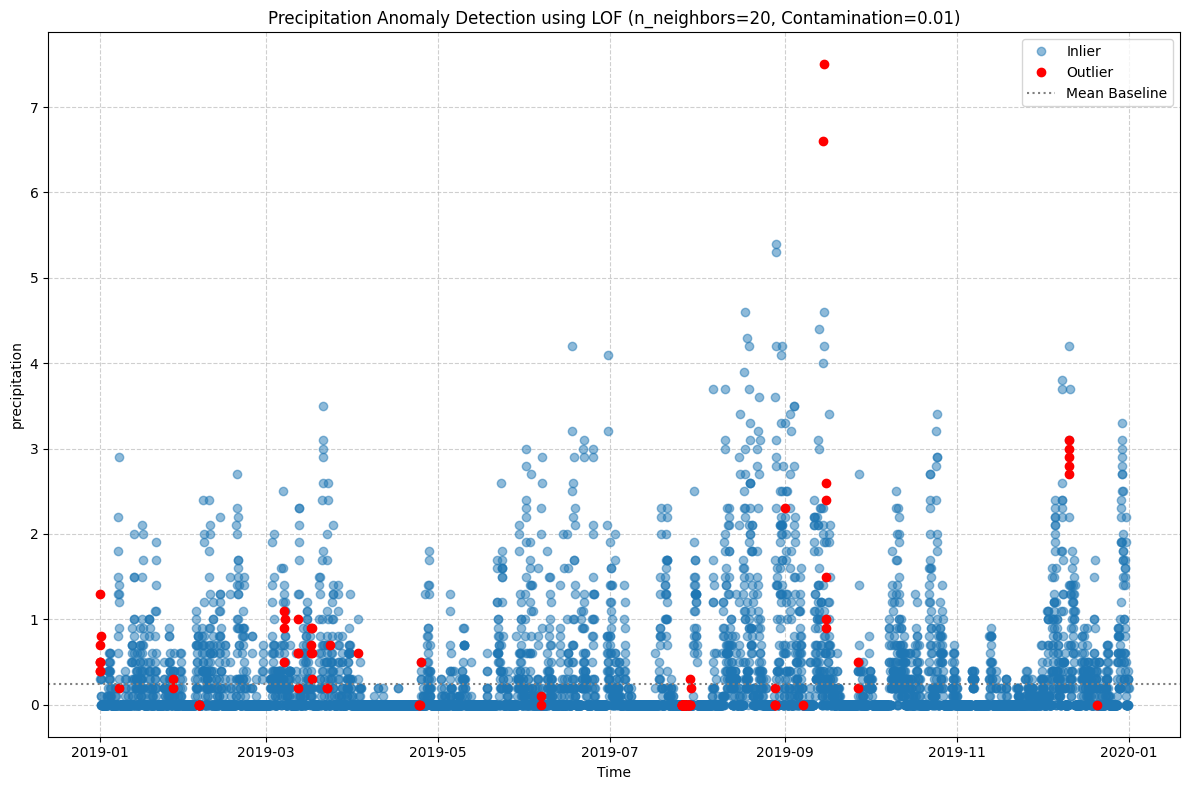

In [11]:
# Test 1 (Requires df_Bergen to be loaded) ---

test1_neighbors=20
test1_contamination=0.01
fig1, summary1, stats1 = calculate_LOF_anomalies(
    df_Bergen, 
    feature_col="precipitation", 
    n_neighbors=test1_neighbors, 
    contamination=test1_contamination)

print(f"\n--- TEST 1 (n_neighbors={test1_neighbors}, Contamination={test1_contamination}) ---")

print("Statistics:", stats1)
print("Outlier Summary Head:\n", summary1.head())


--- TEST 2 (n_neighbors=20, Contamination=0.05) ---
Statistics: {'total_samples': 8760, 'num_outliers': 438, 'outlier_percentage': '5.00%'}
Outlier Summary Head:
                      Precipitation  LOF_Score  Median_Baseline  \
time                                                             
2019-01-01 04:00:00           0.50      -2.60             0.00   
2019-01-01 06:00:00           0.40      -2.59             0.00   
2019-01-01 05:00:00           1.30      -2.53             0.00   
2019-01-01 03:00:00           0.70      -2.38             0.00   
2019-01-01 07:00:00           0.50      -2.35             0.00   

                     Absolute_Deviation  Temperature  Wind_Gusts  
time                                                              
2019-01-01 04:00:00                0.26         7.00       28.50  
2019-01-01 06:00:00                0.16         6.50       34.70  
2019-01-01 05:00:00                1.06         6.50       34.30  
2019-01-01 03:00:00                0.4

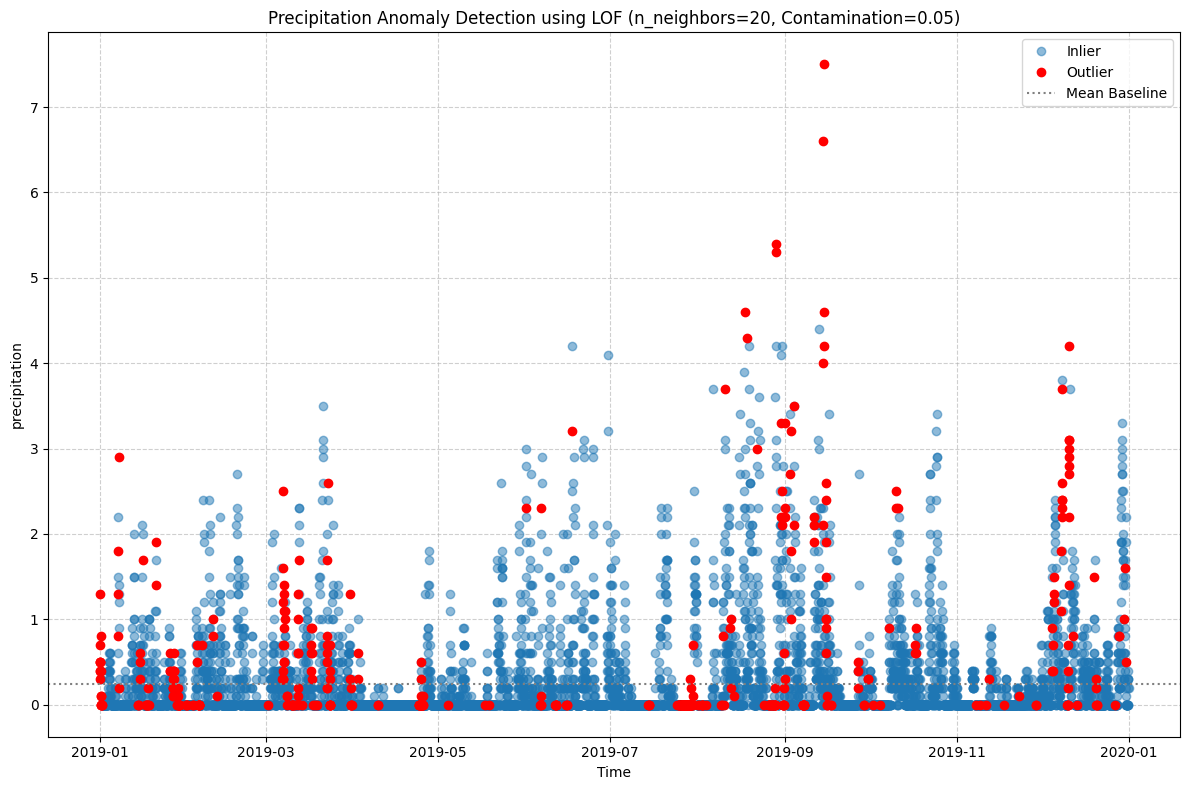

In [12]:
# Test 2 (Requires df_Bergen to be loaded) ---

test2_neighbors=20
test2_contamination=0.05
fig2, summary2, stats2 = calculate_LOF_anomalies(
    df_Bergen, 
    feature_col="precipitation", 
    n_neighbors=test2_neighbors, 
    contamination=test2_contamination)

print(f"\n--- TEST 2 (n_neighbors={test2_neighbors}, Contamination={test2_contamination}) ---")

print("Statistics:", stats2)
print("Outlier Summary Head:\n", summary2.head())

### Seasonal-Trend decomposition using LOESS (STL)
- Perform LOESS on the production data from elbub   
(downloaded in part 1 of the project) and plot its decomposition.
    - Let the electricity price area, production group, period length, seasonal smoother,   
    trend smoother and robust (true/false) be parameters, and give each of them sensible defaults.
    - Wrap this in a function that returns the plot, and test the function.

In [13]:
import pandas as pd
import json
import os

def load_elbub_data(filepath='elbub_data.json'):
    """
    Loads nested elbub JSON data, which is a list of dictionaries, 
    extracting production data from ALL available price areas.
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
            
        all_data_frames = []
        
        # 1. Iterate through the top-level list
        # Each item in 'data' is a dictionary corresponding to a block (like NO1, NO2, etc.)
        for block in data:
            # Check if the block is the one containing time-series attributes
            if 'attributes' in block and 'productionPerGroupMbaHour' in block['attributes']:
                
                attributes = block['attributes']
                
                # Extract the price area name for filtering later
                area_name = attributes.get('name') 
                
                # Extract the list of time-series records
                production_list = attributes['productionPerGroupMbaHour']
                
                # Create a temporary DataFrame for this block
                df_area = pd.DataFrame(production_list)
                
                # Add the area name to all rows for filtering/grouping
                df_area['priceArea'] = area_name
                
                all_data_frames.append(df_area)
        
        if not all_data_frames:
            raise ValueError("No production data blocks found in the JSON file.")

        # 2. Concatenate all price areas into a single DataFrame
        df_full = pd.concat(all_data_frames, ignore_index=True)
        
        # 3. Clean and process the combined DataFrame
        df_full['startTime'] = pd.to_datetime(df_full['startTime'], utc=True)
        df_full = df_full.set_index('startTime').sort_index()
        
        # Ensure quantity is numeric
        df_full['quantityKwh'] = pd.to_numeric(df_full['quantityKwh'], errors='coerce')
        
        return df_full
        
    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error loading elbub data. Check file structure. Error: {e}")
        return pd.DataFrame()

repo_root = os.path.abspath(os.path.join(os.path.dirname(''), '..')) 
print (repo_root)
DOWNLOADS_FOLDER = os.path.join(repo_root, 'downloads')
filename = 'Production_per_group_mad_hours_2021.json'
FILE_PATH = DOWNLOADS_FOLDER + '\\' + filename

df_elbub = load_elbub_data(FILE_PATH)
if not df_elbub.empty:
     print(df_elbub.head())
     print(df_elbub.tail())

c:\Users\oriek\IND320\IND320-Projectwork-Orie-assignment3
                                             endTime  \
startTime                                              
2020-12-31 23:00:00+00:00  2021-01-01T01:00:00+01:00   
2020-12-31 23:00:00+00:00  2021-01-01T01:00:00+01:00   
2020-12-31 23:00:00+00:00  2021-01-01T01:00:00+01:00   
2020-12-31 23:00:00+00:00  2021-01-01T01:00:00+01:00   
2020-12-31 23:00:00+00:00  2021-01-01T01:00:00+01:00   

                                     lastUpdatedTime priceArea  \
startTime                                                        
2020-12-31 23:00:00+00:00  2024-12-20T10:35:40+01:00       NO1   
2020-12-31 23:00:00+00:00  2024-12-20T10:35:40+01:00       NO3   
2020-12-31 23:00:00+00:00  2024-12-20T10:35:40+01:00       NO1   
2020-12-31 23:00:00+00:00  2024-12-20T10:35:40+01:00       NO5   
2020-12-31 23:00:00+00:00  2024-12-20T10:35:40+01:00       NO3   

                          productionGroup  quantityKwh  
startTime                    

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from typing import Tuple, Dict, Any

def decompose_elbub_production(
    df: pd.DataFrame,
    area: str = 'NO3',
    prod_group: str = 'hydro',
    period: int = 24,           # Sensible default: 24 hours (daily seasonality)
    seasonal_smoother: int = 13, # Sensible default: odd number > 7, controls seasonal smoothness
    trend_smoother: int = 501,  # Sensible default: large odd number for annual trend
    robust: bool = True,        # Sensible default: True (robust to outliers/anomalies)
    prod_col: str = 'quantityKwh'
) -> plt.Figure:
    """
    Performs STL decomposition (LOESS) on electricity production data and plots the result.

    Args:
        df (pd.DataFrame): The full DataFrame loaded from elbub JSON.
        area (str): Electricity price area (e.g., 'NO1').
        prod_group (str): Production group (e.g., 'hydro').
        period (int): Length of the seasonal cycle (e.g., 24 for daily, 24*7 for weekly).
        seasonal_smoother (int): Odd span (window size) for seasonal smoothing (odd, typically < period).
        trend_smoother (int): Odd span for trend smoothing (must be odd).
        robust (bool): If True, uses robust fitting (less sensitive to outliers).
        prod_col (str): The name of the production column.

    Returns:
        plt.Figure: The Matplotlib Figure object containing the decomposition plot.
    """
    
    # Price Area filter
    area_filter = df['priceArea'].str.strip() == area
    
    # prod_group filter
    prod_group_filter = df['productionGroup'].str.strip() == prod_group
    
    # Apply the combined filter
    df_filtered = df[area_filter & prod_group_filter].copy()
    
    # Check for emptiness
    if df_filtered.empty:
        # Raise an informative error based on the original input
        raise ValueError(f"No data found for Area: {area} and Group: {prod_group}. Check data values.")
    
    # Ensure the Series is continuous and sorted
    series = df_filtered[prod_col].sort_index()
  
    # Check if the series is long enough
    min_length = period + 1
    if len(series) < min_length:
        raise ValueError(f"Series too short for period {period}. Requires at least {min_length} observations.")
    
    try:
        # The key parameters match the function arguments:
        res = STL(
            series, 
            period=period, 
            seasonal=seasonal_smoother, 
            trend=trend_smoother, 
            robust=robust
        ).fit()
    except Exception as e:
        print(f"STL decomposition failed. Check period and smoother spans: {e}")
        return None

    # Plot the Decomposition
    fig = plt.figure(figsize=(20, 30))
    fig = res.plot(fig)
    
    for ax in fig.axes:
        # Rotate x-axis labels by 45 degrees for better readability
        ax.tick_params(axis='x', rotation=45)
        
    # Customizing the Plot Title for clarity
    fig.suptitle(
        f'STL Decomposition of {prod_group} Production in {area}, 2021', 
        fontsize=12, 
        y=1.02
    )
    
    # Add parameter summary to the plot (optional, but helpful for testing)
    fig.text(0.02, 0.03, 
             f'P={period}, S_span={seasonal_smoother}, T_span={trend_smoother}, Robust={robust}', 
             fontsize=8, alpha=0.7, transform=fig.transFigure)
    
    plt.tight_layout()
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    
    return fig

--- Test 1 ---


<Figure size 2000x3000 with 0 Axes>

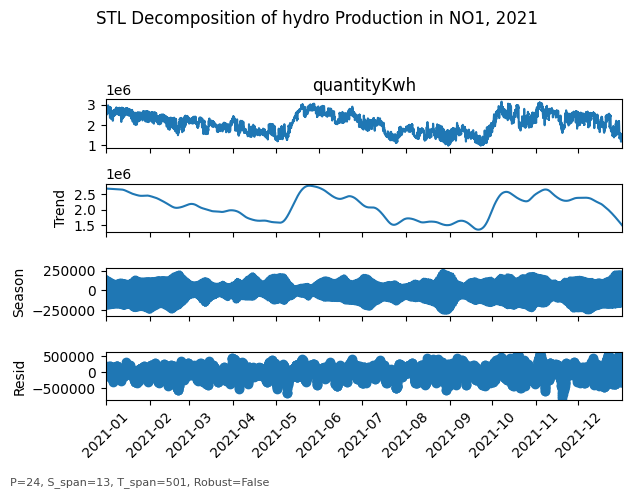

In [15]:
# Test 1: Using all default parameters (Daily seasonality)
daily = 24
period = daily
selected_area = 'NO1'
selected_prod_group = 'hydro'

print("--- Test 1 ---")
plot1 = decompose_elbub_production(
    df_elbub, 
    area = selected_area,
    prod_group = selected_prod_group,
    period=period,
    robust=False)
plt.show() # Uncomment to display the plot


--- TEST 2  ---


<Figure size 2000x3000 with 0 Axes>

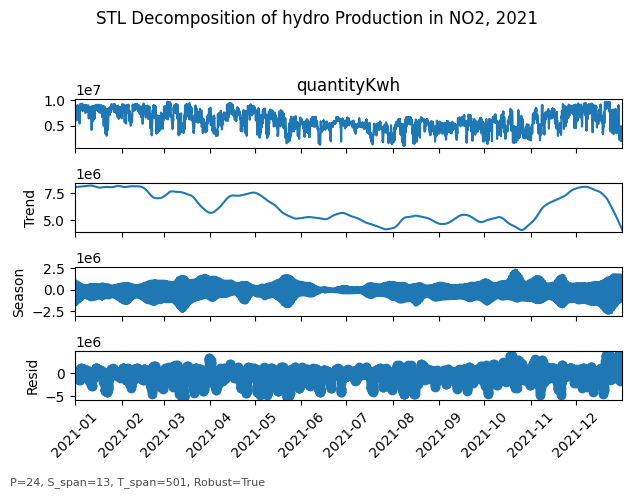

In [16]:
# Test 2
daily = 24
period = daily
selected_area = 'NO2'
selected_prod_group = 'hydro'

print(f"\n--- TEST 2  ---")

plot2 = decompose_elbub_production(
    df_elbub, 
    area = selected_area,
    prod_group = selected_prod_group,
    period=period,
    robust=True)
plt.show() 


--- TEST 3 ---


<Figure size 2000x3000 with 0 Axes>

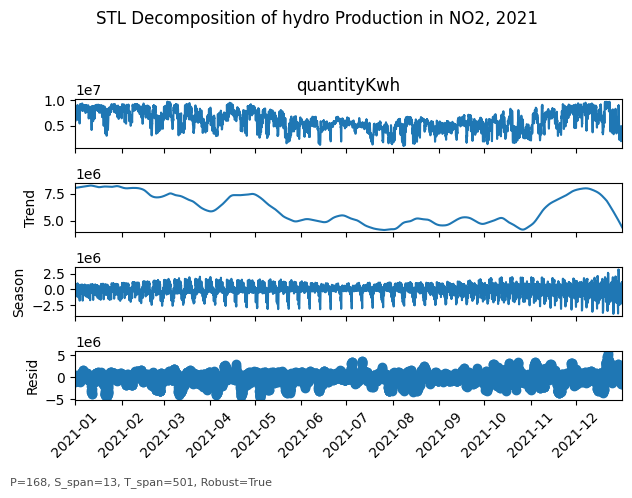

In [17]:
# Test 3: Adjusting parameters
weekly = 24*7
period = weekly
selected_area = 'NO2'
selected_prod_group = 'hydro'

plot3 = decompose_elbub_production(
    df_elbub, 
    period=period,
    area = selected_area,
    prod_group = selected_prod_group,
    robust=True
)

print(f"\n--- TEST 3 ---")
plt.show()

### Spectrogram
- Create a spectrogram based on the production data from elhub.
    - Let the electricity price area, production group, window length and window overlap be parameters,   
    and give each of them sensible defaults.
    - Wrap this in a function that returns the plot, and test the function.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from typing import Tuple

def plot_spectrogram_decomposition(
    df_elbub: pd.DataFrame,
    area: str,
    prod_group: str,
    window_length: int = 168,
    window_overlap: int = 84,
    figsize: Tuple[float, float] = (12, 8)
) -> plt.Figure:
    """
    Filters the Elhub data and generates a two-panel plot:
    1. Time Series of the filtered data.
    2. Spectrogram (STFT) of the filtered data.

    Args:
        df_elbub (pd.DataFrame): The combined Elhub data DataFrame.
        area (str): The price area (e.g., 'NO3').
        prod_group (str): The production group (e.g., 'hydro').
        window_length (int): The STFT window length (nperseg). Defaults to 168 (weekly).
        figsize (Tuple[float, float]): Size of the output figure.
        
    Returns:
        plt.Figure: The Matplotlib Figure object.
    """
    
    # Setup and Filtering
    df_spectrogram = df_elbub.copy()
    # window_overlap = window_length // 2 # noverlap is 50% of nperseg

    # Filtering with whitespace-removed
    area_filter = df_spectrogram['priceArea'].str.strip() == area
    prod_group_filter = df_spectrogram['productionGroup'].str.strip() == prod_group

    # Apply the combined filter
    df_filtered2 = df_spectrogram[area_filter & prod_group_filter].copy()

    # Basic check to prevent crash if data is empty
    if df_filtered2.empty:
        print(f"Error: No data found for Area: {area} and Group: {prod_group}. Cannot perform STFT.")
        return plt.figure()
        
    # --- 1. Perform STFT ---
    f, t, Zxx = stft(
        df_filtered2['quantityKwh'], 
        fs = 1.0, # Data is hourly (1 sample per hour)
        nperseg = window_length, 
        noverlap = window_overlap
    )

    # --- 2. Map STFT times back to actual datetimes (using the time vector t) ---
    # The time vector 't' is measured in hours (samples) since fs=1.0
    # start_time = df_filtered2.index[0]
    # The interval between samples is 1 hour (1 day / 24 samples)
    # time_step = pd.Timedelta(hours=1) 
    
    # Map the numerical time vector 't' (in hours) back to datetime objects
    # datetime_labels = [start_time + i * time_step for i in t]

    start_time = df_filtered2.index[0]
    time_step = pd.Timedelta(hours=1) 
    
    # IMPORTANT FIX: Use the short time vector (t_stft) from the STFT result
    datetime_labels = [start_time + pd.Timedelta(hours=i) for i in t]
    
    # --- 3. Plotting ---
    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # Top Plot (Time Series)
    axs[0].plot(df_filtered2.index, df_filtered2['quantityKwh'], label='Production')
    axs[0].set_ylabel('Amplitude (QuantityKwh)')
    axs[0].set_title(f'Time Series and Spectrogram for {prod_group} in {area} (Window={window_length}h, Overlap={window_overlap}h)')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # Bottom Plot (Spectrogram)
    pcm = axs[1].pcolormesh(
        datetime_labels, 
        f, 
        np.abs(Zxx),
        shading='auto', 
        vmin=0,
        vmax=np.max(np.abs(Zxx)) / 2
    )
    axs[1].set_ylabel('Frequency [cycles/hour]')
    axs[1].set_xlabel('Time')
    fig.colorbar(pcm, ax=axs[1], label='Amplitude')

    # Rotate X-labels for better readability
    for ax in axs:
        ax.tick_params(axis='x', rotation=45) 
        
    plt.tight_layout()
    return fig

--- Test 1: DailySpectrogram ---


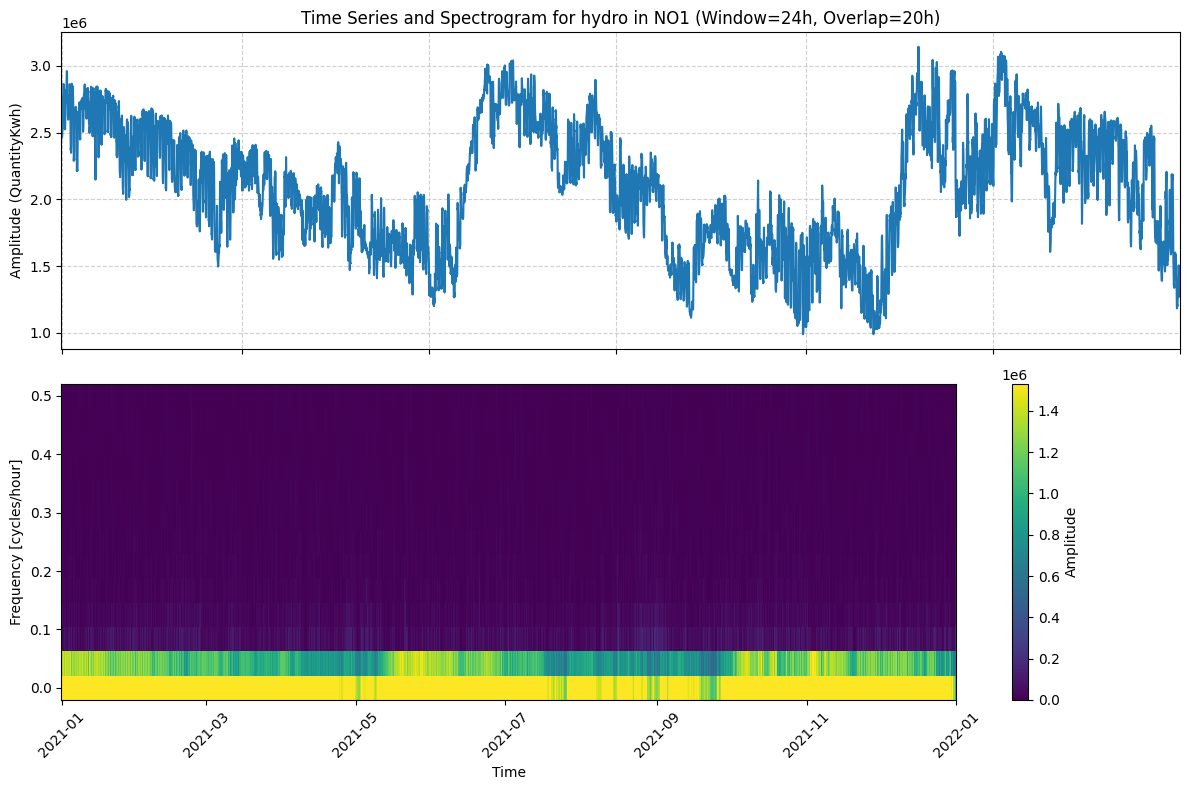

In [21]:
# Test 1
selected_area = 'NO1'
selected_prod_group = 'hydro'
selected_window_length = 24
selected_window_overlap = 20

print("--- Test 1: DailySpectrogram ---")
fig_daily = plot_spectrogram_decomposition(
    df_elbub, 
    area = selected_area, 
    prod_group = selected_prod_group, 
    window_length = selected_window_length,
    window_overlap = selected_window_overlap)
plt.show()

--- Test 2: Weekly spectrogram---


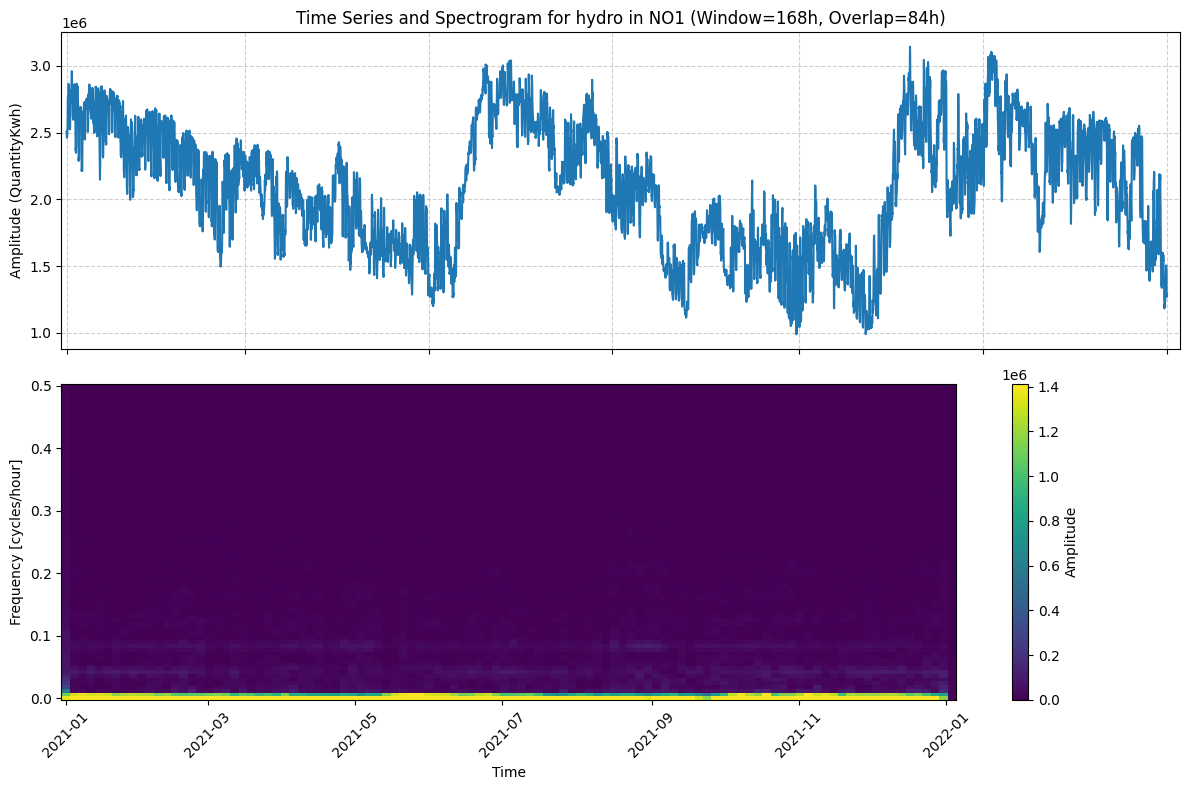

In [22]:
# Test 2
selected_area = 'NO1'
selected_prod_group = 'hydro'
selected_window_length = 24 * 7
selected_window_overlap = selected_window_length // 2

print("--- Test 2: Weekly spectrogram---")
fig_weekly = plot_spectrogram_decomposition(
    df_elbub, 
    area = selected_area, 
    prod_group = selected_prod_group, 
    window_length = selected_window_length,
    window_overlap = selected_window_overlap)
plt.show()